# TITLE:
# CUSTOMER SEGMENTATION USING K-MEANS
# Developed By: Aiman Afzaal

# Objective of this project
- To analyze customer data from the Mall Customers dataset.
- To segment customers based on behavior using K-Means Clustering.
- To identify patterns in income, age, and spending habits.
- To visualize clusters using Principal Component Analysis (PCA) and t-distributed Stochastic Neighbor Embedding.
- To generate meaningful customer groups for business insights.
- To suggest targeted marketing strategies for each segment.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

In this step, we import essential Python libraries.
- pandas & numpy helps data handling
- matplotlib & seaborn helps visualization
- StandardScaler helps feature scaling
- KMeans helps clustering algorithm
- PCA & t-SNE helps dimensionality reduction techniques

# Load Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


The dataset "Mall_Customers.csv" is loaded using pandas.
It contains customer information such as:
- CustomerID
- Gender
- Age
- Annual Income
- Spending Score
- We display the first few rows to understand the structure of the data.

# Exploratory Data Analysis

# Basic Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


This helps identify data types and check for missing values.

# Check missing value

In [4]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

We check for missing values to ensure data quality. No missing values means dataset is clean.

# Statistical Summary

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


This gives mean, median, and distribution of numerical features.

# Distribution Plot

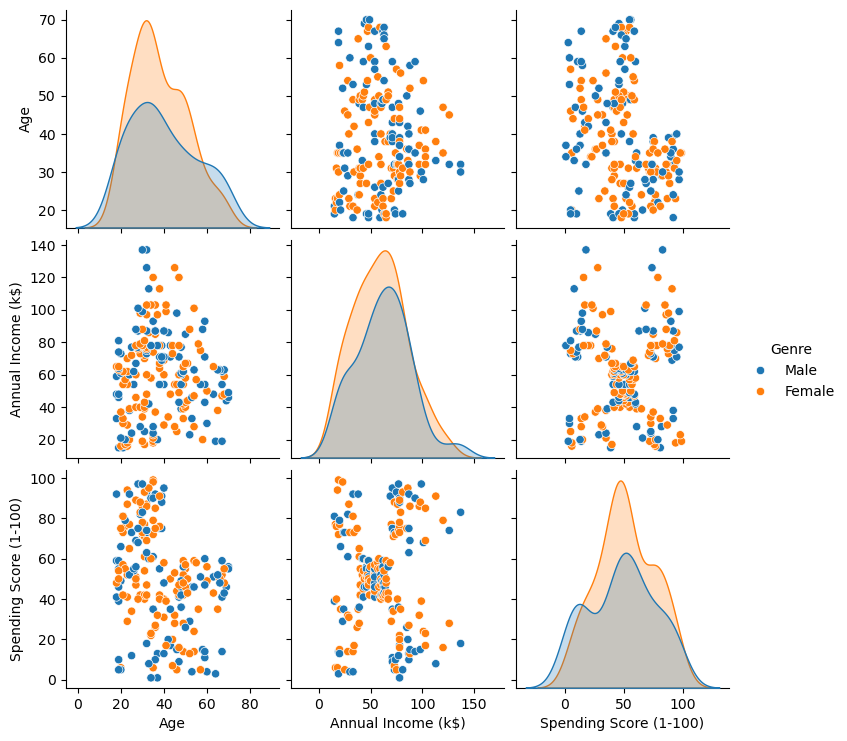

In [8]:
sns.pairplot(df.drop('CustomerID', axis=1), hue='Genre')
plt.show()

Pairplot helps visualize relationships between:
- Age
- Income
- Spending Score
- It also shows gender distribution patterns.

# Feature Selection And Encoding

In [11]:
df_encoded = df.copy()

# Convert Gender into numeric
df_encoded['Genre'] = df_encoded['Genre'].map({'Male': 0, 'Female': 1})

features = df_encoded[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

Since machine learning models require numeric input:
- Gender is converted into binary values.
- Relevant features are selected for clustering.

# Feature scaling 

In [12]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Scaling is applied so that all features contribute equally to clustering.
Without scaling, income or age could dominate results.

# Elbow Method (Find Optimal K)

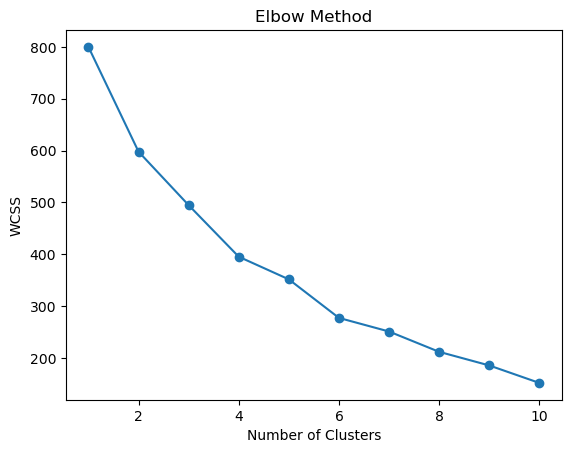

In [13]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

- The Elbow Method helps determine the optimal number of clusters (K).
- We choose the point where WCSS stops decreasing sharply (the “elbow”).
- Usually for this dataset: K = 5

# Apply K-means Clustering

In [14]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

df_encoded['Cluster'] = clusters
df_encoded.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,0,19,15,39,2
1,2,0,21,15,81,2
2,3,1,20,16,6,4
3,4,1,23,16,77,4
4,5,1,31,17,40,4


K-Means groups customers into 5 clusters based on similarity in:
- Age
- Income
- Spending Score
- Each customer is assigned a cluster label.

# Visualize Cluster

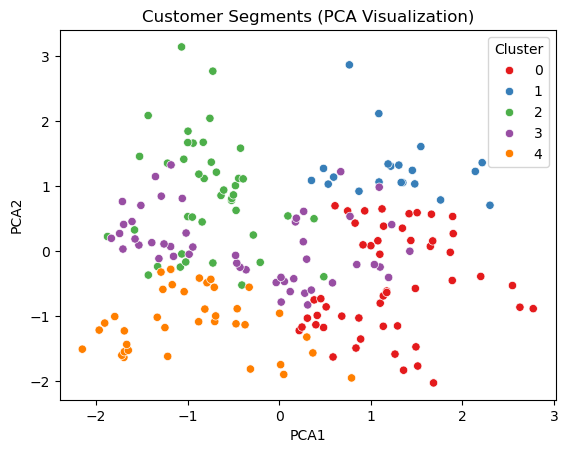

In [15]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

df_encoded['PCA1'] = pca_result[:, 0]
df_encoded['PCA2'] = pca_result[:, 1]

sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='Set1',
    data=df_encoded
)

plt.title("Customer Segments (PCA Visualization)")
plt.show()

- PCA reduces data from 4D to 2D for visualization.
- Each color represents a different customer segment.

# t-SNE Visualization

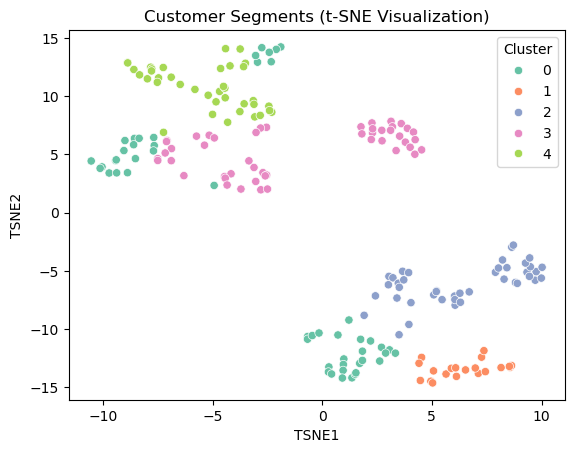

In [16]:
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(scaled_features)

df_encoded['TSNE1'] = tsne_result[:, 0]
df_encoded['TSNE2'] = tsne_result[:, 1]

sns.scatterplot(
    x='TSNE1', y='TSNE2',
    hue='Cluster',
    palette='Set2',
    data=df_encoded
)

plt.title("Customer Segments (t-SNE Visualization)")
plt.show()

- t-SNE gives a more detailed visualization of clusters by preserving local structure.
- It is especially useful for complex datasets.

# Cluster Analysis 

In [17]:
df_encoded.groupby('Cluster').mean()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),PCA1,PCA2,TSNE1,TSNE2
Cluster,,,,,,,,,
0,65.333333,0.490196,56.470588,46.098039,39.313725,1.196512,-0.509010,-2.779034,-2.672580
1,159.500000,0.000000,39.500000,85.150000,14.050000,1.254732,1.275794,6.440965,-13.440892
2,100.809524,0.000000,28.690476,60.904762,70.238095,-0.771673,0.873183,6.372858,-6.093809
3,151.510204,1.000000,37.897959,82.122449,54.448980,-0.373001,0.098257,-1.279231,5.410304
4,50.526316,1.000000,27.315789,38.842105,56.210526,-0.932353,-1.080123,-5.333132,10.792930


This step helps understand characteristics of each cluster:
- Average income
- Spending score
- Age group
- This is the most important step for marketing insights.

# Marketing Strategies 

## Cluster 0: High Income, High Spending
- Strategy: Premium offers, loyalty programs
- Focus: Luxury products, VIP membership
## Cluster 1: Low Income, High Spending
- Strategy: Discounts, budget-friendly offers
- Focus: Flash sales, cashback
## Cluster 2: High Income, Low Spending
- Strategy: Targeted marketing, product awareness
- Focus: Premium product promotions
## Cluster 3: Low Income, Low Spending
- Strategy: Retention campaigns
- Focus: Basic essential products
## Cluster 4: Medium Income, Moderate Spending
- Strategy: Balanced promotions
- Focus: Seasonal offers, bundle deals

# Report Summary
Customer segmentation using K-Means clustering successfully divided customers into distinct groups based on income, age, and spending behavior. PCA and t-SNE visualization confirmed clear cluster separation. These insights can help businesses design personalized marketing strategies for improved customer targeting and revenue optimization.